In [28]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [29]:
df = pd.read_csv('./dataset/cleaned_dataset.csv')

X = df.drop(columns=['Depression']).values
y = df['Depression'].values

In [30]:
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max')

history = model.fit(
    X, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step - accuracy: 0.8273 - loss: 0.3857 - precision: 0.8366 - recall: 0.8754 - val_accuracy: 0.8452 - val_loss: 0.3591 - val_precision: 0.8412 - val_recall: 0.9092
Epoch 2/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - accuracy: 0.8499 - loss: 0.3483 - precision: 0.8573 - recall: 0.8916 - val_accuracy: 0.8468 - val_loss: 0.3594 - val_precision: 0.8507 - val_recall: 0.8978
Epoch 3/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - accuracy: 0.8505 - loss: 0.3447 - precision: 0.8605 - recall: 0.8882 - val_accuracy: 0.8483 - val_loss: 0.3566 - val_precision: 0.8564 - val_recall: 0.8925
Epoch 4/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - accuracy: 0.8506 - loss: 0.3414 - precision: 0.8595 - recall: 0.8898 - val_accuracy: 0.8472 - val_loss: 0.3574 - val_precision: 0.8510 - val_recall: 0.8982
Epoch 5/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.8524 - loss: 0.3395 - precision: 0.8618 - recall: 0.8901 - val_accuracy: 0.8461 - va

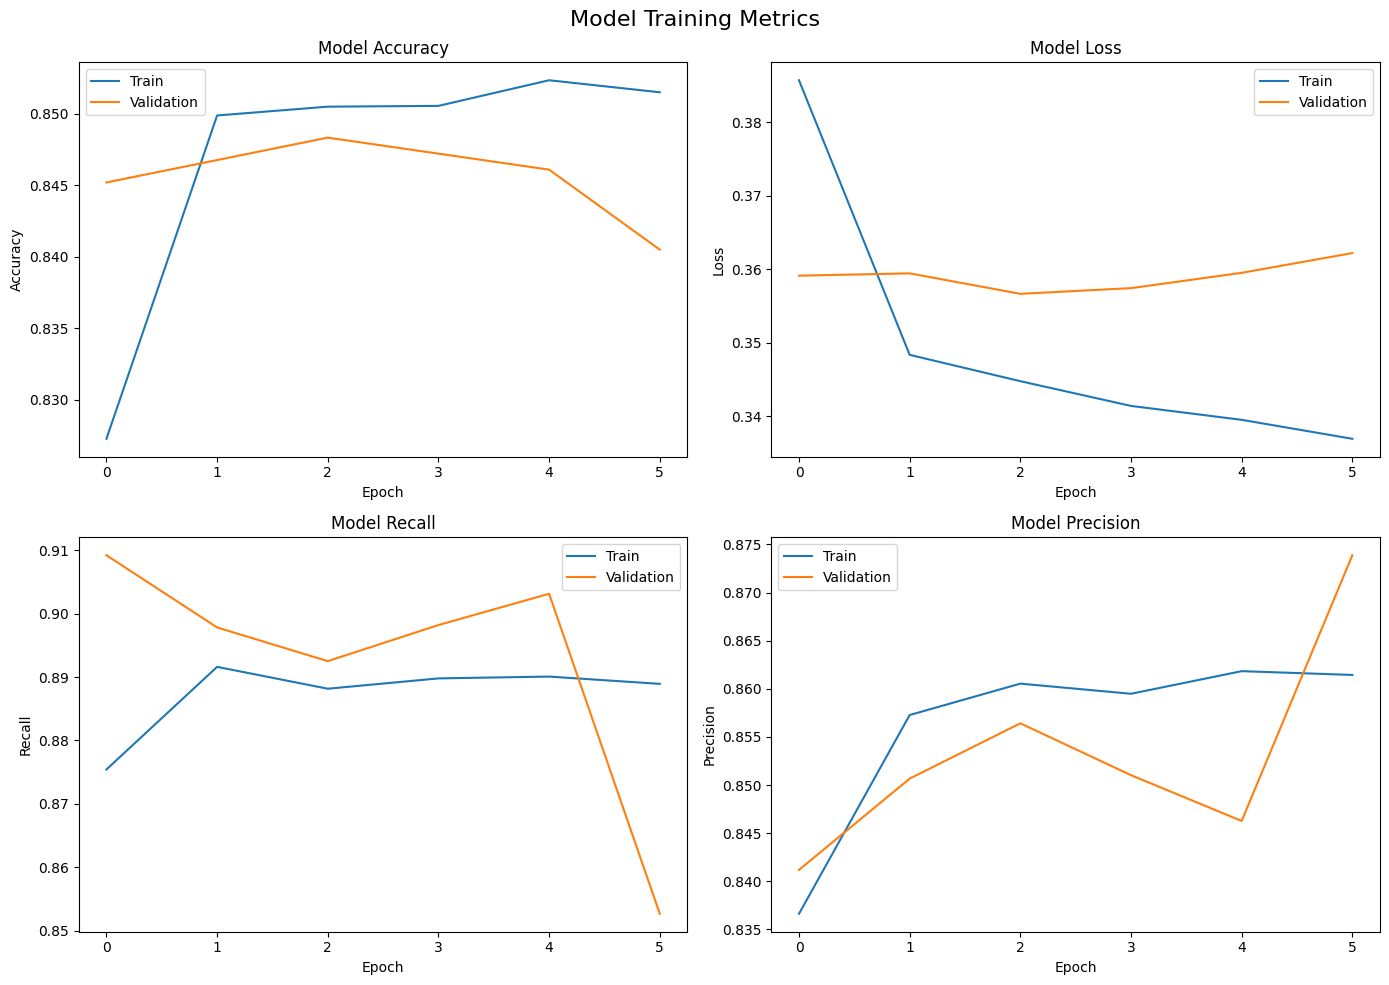

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'],     label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history.history['loss'],     label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Recall
axes[1, 0].plot(history.history['recall'],     label='Train')
axes[1, 0].plot(history.history['val_recall'], label='Validation')
axes[1, 0].set_title('Model Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(history.history['precision'],     label='Train')
axes[1, 1].plot(history.history['val_precision'], label='Validation')
axes[1, 1].set_title('Model Precision')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.suptitle('Model Training Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('./assets/training_metrics.png')
plt.show()

698/698 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step


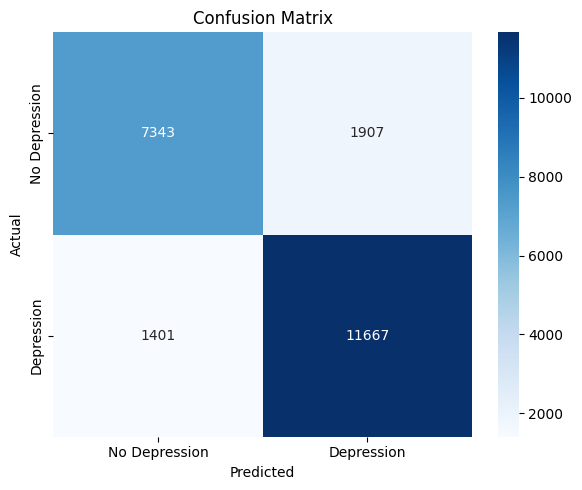

In [35]:
y_pred = (model.predict(X) > 0.5).astype(int)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('./assets/confusion_matrix.png')
plt.show()

In [36]:
y_pred = (model.predict(X) > 0.5).astype(int)

report = classification_report(y, y_pred, target_names=['No Depression', 'Depression'])
print(report)

698/698 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
               precision    recall  f1-score   support

No Depression       0.84      0.79      0.82      9250
   Depression       0.86      0.89      0.88     13068

     accuracy                           0.85     22318
    macro avg       0.85      0.84      0.85     22318
 weighted avg       0.85      0.85      0.85     22318

